<a href="https://colab.research.google.com/github/raquelgomes2608/Cesar/blob/main/Trabalho%20Final/Trabalho%20Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Atividade Final - Redes Neurais

Equipe:
*   João Paulo Araújo - jpaf@cesar.school
*   Lethycia Farias - lmf5@cesar.school
*   Raquel Silva - rgs5@cesar.school

Dataset: https://www.kaggle.com/datasets/muratkokludataset/pistachio-dataset



        

In [1]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from IPython import display

In [2]:
!pwd

/content


In [3]:
#!/bin/bash
!curl -L -o /content/pistachio-dataset.zip https://www.kaggle.com/api/v1/datasets/download/muratkokludataset/pistachio-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1859k  100 1859k    0     0  4010k      0 --:--:-- --:--:-- --:--:-- 44.2M


In [4]:
!unzip /content/pistachio-dataset.zip

Archive:  /content/pistachio-dataset.zip
  inflating: Pistachio_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset.arff  
  inflating: Pistachio_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset.xls  
  inflating: Pistachio_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset.xlsx  
  inflating: Pistachio_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset_Citation_Request.txt  
  inflating: Pistachio_Dataset/Pistachio_28_Features_Dataset/Pistachio_28_Features_Dataset.arff  
  inflating: Pistachio_Dataset/Pistachio_28_Features_Dataset/Pistachio_28_Features_Dataset.xls  
  inflating: Pistachio_Dataset/Pistachio_28_Features_Dataset/Pistachio_28_Features_Dataset.xlsx  
  inflating: Pistachio_Dataset/Pistachio_28_Features_Dataset/Pistachio_28_Features_Dataset_Citation_Request.txt  


In [5]:
df = pd.read_excel('Pistachio_Dataset/Pistachio_16_Features_Dataset/Pistachio_16_Features_Dataset.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2148 entries, 0 to 2147
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AREA           2148 non-null   int64  
 1   PERIMETER      2148 non-null   float64
 2   MAJOR_AXIS     2148 non-null   float64
 3   MINOR_AXIS     2148 non-null   float64
 4   ECCENTRICITY   2148 non-null   float64
 5   EQDIASQ        2148 non-null   float64
 6   SOLIDITY       2148 non-null   float64
 7   CONVEX_AREA    2148 non-null   int64  
 8   EXTENT         2148 non-null   float64
 9   ASPECT_RATIO   2148 non-null   float64
 10  ROUNDNESS      2148 non-null   float64
 11  COMPACTNESS    2148 non-null   float64
 12  SHAPEFACTOR_1  2148 non-null   float64
 13  SHAPEFACTOR_2  2148 non-null   float64
 14  SHAPEFACTOR_3  2148 non-null   float64
 15  SHAPEFACTOR_4  2148 non-null   float64
 16  Class          2148 non-null   object 
dtypes: float64(14), int64(2), object(1)
memory usage: 28

In [6]:
df.head(5)

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,ROUNDNESS,COMPACTNESS,SHAPEFACTOR_1,SHAPEFACTOR_2,SHAPEFACTOR_3,SHAPEFACTOR_4,Class
0,63391,1568.405,390.3396,236.7461,0.7951,284.0984,0.8665,73160,0.6394,1.6488,0.3238,0.7278,0.0062,0.0037,0.5297,0.8734,Kirmizi_Pistachio
1,68358,1942.187,410.8594,234.7525,0.8207,295.0188,0.8765,77991,0.6772,1.7502,0.2277,0.7181,0.0060,0.0034,0.5156,0.9024,Kirmizi_Pistachio
2,73589,1246.538,452.3630,220.5547,0.8731,306.0987,0.9172,80234,0.7127,2.0510,0.5951,0.6767,0.0061,0.0030,0.4579,0.9391,Kirmizi_Pistachio
3,71106,1445.261,429.5291,216.0765,0.8643,300.8903,0.9589,74153,0.7028,1.9879,0.4278,0.7005,0.0060,0.0030,0.4907,0.9755,Kirmizi_Pistachio
4,80087,1251.524,469.3783,220.9344,0.8823,319.3273,0.9657,82929,0.7459,2.1245,0.6425,0.6803,0.0059,0.0028,0.4628,0.9833,Kirmizi_Pistachio


In [7]:
encoder = LabelEncoder()
df['Class'] = encoder.fit_transform(df['Class'])

In [8]:
df['Class'].unique()

array([0, 1])

In [9]:
X = df.drop(['Class'], axis=1)
y = df['Class']

In [10]:
# Normalize X
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

In [11]:
X_tensor = torch.FloatTensor(X_scaled)

Y_tensor = torch.LongTensor(y)

In [12]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(X.shape[1], 15),
            nn.ReLU(),
            nn.Linear(15, 15),
            nn.ReLU(),
            nn.Linear(15, 15),
            nn.ReLU(),
            nn.Linear(15,2),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model = Modelo()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=16, out_features=15, bias=True)
    (1): ReLU()
    (2): Linear(in_features=15, out_features=15, bias=True)
    (3): ReLU()
    (4): Linear(in_features=15, out_features=15, bias=True)
    (5): ReLU()
    (6): Linear(in_features=15, out_features=2, bias=True)
  )
)


In [13]:
def predict(model, inputs):
    outputs = model(Variable(inputs))
    _, predicts = torch.max(outputs, 1)

    return predicts.data.numpy()

In [14]:
class BoundaryPlotter():
    def __init__(self, model, X, Y, n_epoch, filepath=None, h = .01):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        self.filepath = filepath
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        self.xx, self.yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        self.loss_hist = []
        self.val_loss_hist = []
        self.X_grid = np.c_[self.xx.ravel(), self.yy.ravel()]

        #Gráficos a serem mostrados pelo callback
        self.fig = plt.figure(figsize=(8, 4), dpi=100)
        self.ax1 = self.fig.add_subplot(1, 2, 1)
        self.ax1.set_xlim(0, nb_epoch)
        self.ax1.set_xlabel('Epoca')#,fontsize=28)
        self.ax1.set_ylabel('Perda')#,fontsize=28)
        self.ax1.plot([],[],'b',linewidth = 2.0,label = "Treino")
        self.ax1.grid(True)

        self.ax2 = self.fig.add_subplot(1, 2, 2)
        self.ax2.set_xlim(X[:,0].min(), X[:,0].max())
        self.ax2.set_ylim(X[:,1].min(), X[:,1].max())
        self.ax2.set_xlabel('Dados Dataset')#,fontsize=28)
        self.ax2.set_ylabel('Classe Pistache')#,fontsize=28)

    def on_train_begin(self, logs={}):
        display.display(self.fig)
        display.clear_output(wait=True)

    def on_epoch_end(self, epoch, logs={}):
      if 'loss' in logs.keys():
          self.loss_hist.append(logs['loss'])

          if epoch % 250 == 0:
              self.ax1.plot(np.arange(epoch + 1), self.loss_hist, 'b', linewidth=2.0)

              # Create a full N-dimensional grid for prediction, filling extra dimensions with zeros
              num_model_features = X_scaled.shape[1] # Model expects 16 features
              X_grid_full_dim = np.zeros((self.X_grid.shape[0], num_model_features))
              X_grid_full_dim[:, :2] = self.X_grid # Place the 2D grid values in the first two columns

              Z = predict(self.model, torch.from_numpy(X_grid_full_dim).type(torch.FloatTensor))
              Z = Z.reshape(self.xx.shape)

              self.ax2.pcolormesh(self.xx, self.yy, Z, cmap=plt.cm.Paired)
              colors = np.array(['r', 'y']) # Assuming 2 classes (Kirmizi, Siit) for plotting
              self.ax2.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

              display.display(self.fig)
              display.clear_output(wait=True)

In [15]:
lr = 0.05

optimizer = torch.optim.SGD(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

Final loss: tensor(0.2586)


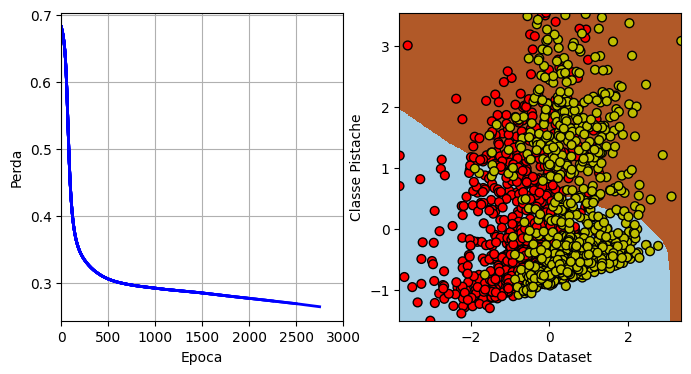

In [16]:
batch_size = 200
nb_epoch = 3000

#Definindo o plotter
boundary_plot = BoundaryPlotter(model, X_scaled, y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(Variable(X_tensor))

    loss = criterion(output, Variable(Y_tensor))

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Final loss:', loss.data)

In [17]:
Y_hat = predict(model, X_tensor)
accuracy = (Y_hat == y).mean()
print()
print('Training Accuracy: ', accuracy)


Training Accuracy:  0.8919925512104283


# **Aprendizados:**
Inicialmente, o modelo apresentou desempenho abaixo do esperado, indicando um possível caso de underfitting, já que não estava conseguindo aprender suficientemente os padrões dos dados. Para solucionar esse problema, foram realizados ajustes nos hiperparâmetros. Com essas modificações, o modelo apresentou uma melhora significativa, alcançando 89% de acurácia. Esse processo permitiu compreender a importância do ajuste dos hiperparâmetros e da análise das métricas para melhorar o desempenho de uma rede neural